# Concatenation model experiments

In [1]:
import os, sys, json
import numpy as np
import torch
import matplotlib.pyplot as plt
from functools import partial
from diffusers.models.unets.unet_2d import UNet2DModel
from diffusers.training_utils import EMAModel

from utils import (
    NpyImageDataset, channel_normalize, channel_denormalize, 
    generate_satellite_track_mask, get_device,
    make_plot, make_difference_plot,
)
from concat.sampler import Sampler

In [2]:
CHECKPOINT_DIR = "checkpoints"          
RUN_NAME       = "run_20260305_113157"           
DATA_ROOT      = "/mnt/sciml/a.sadreev/sea_ice_data"  

N_SAMPLES      = 25      
NUM_TIMESTEPS  = 50
N_TRACKS_RANGE = (1, 4)
IMAGE_SIZE     = (320, 256)

DEVICE = get_device()
print(f"device: {DEVICE}")

with open(os.path.join(DATA_ROOT, "train", "stats.json")) as f:
    stats = json.load(f)
CHANNEL_MEAN = tuple(stats["mean"])
CHANNEL_STD  = tuple(stats["std"])
print(f"channel_mean={CHANNEL_MEAN}  channel_std={CHANNEL_STD}")

device: cuda
channel_mean=(0.1158, 0.1153)  channel_std=(0.3008, 0.3501)


## Загрузка модели

In [3]:
if RUN_NAME is None:
    runs = sorted(d for d in os.listdir(CHECKPOINT_DIR) if d.startswith("run_"))
    assert runs, f"Нет run_* в {CHECKPOINT_DIR}"
    RUN_NAME = runs[-1]
run_dir = os.path.join(CHECKPOINT_DIR, RUN_NAME)
print(f"Используем run: {run_dir}")

cfg_path = os.path.join(run_dir, "config.json")
if os.path.exists(cfg_path):
    with open(cfg_path) as f:
        saved_cfg = json.load(f)
    print(json.dumps({k: v for k, v in saved_cfg.items()
                      if k not in ("channel_mean", "channel_std")}, indent=2))

Используем run: checkpoints/run_20260305_113157


In [4]:
model = UNet2DModel(
    sample_size=IMAGE_SIZE,
    in_channels=7,
    out_channels=2,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 512, 512),
    down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D",
                      "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D",
                    "UpBlock2D", "UpBlock2D"),
)

ema_path = os.path.join(run_dir, "ema_best_model.pth")
assert os.path.exists(ema_path), f"Файл не найден: {ema_path}"

ema = EMAModel(model.parameters(), decay=0.999)
ema.load_state_dict(torch.load(ema_path, map_location="cpu"))
ema.copy_to(model.parameters())

model.eval().to(DEVICE)
sampler = Sampler(model)
print("Модель загружена.")

/tmp/ipykernel_888867/2292551855.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ema.load_state_dict(torch.load(ema_path, map_location="cpu"))


Модель загружена.


## Валидационные данные — 18 равномерно расставленных сэмплов

In [5]:
transform = partial(channel_normalize, channel_mean=CHANNEL_MEAN, channel_std=CHANNEL_STD)

val_dataset = NpyImageDataset(
    folder=os.path.join(DATA_ROOT, "valid"),
    transform=transform,
    preload=False,
    mmap_mode='r',
)
print(f"Всего val-сэмплов: {len(val_dataset)}")

indices = np.linspace(0, len(val_dataset) - 1, N_SAMPLES, dtype=int)
print(f"Выбраны индексы: {indices}")

clean_images = torch.stack([val_dataset[i] for i in indices]).to(DEVICE)  # (12, 2, H, W)
print(f"clean_images shape: {clean_images.shape}")

Всего val-сэмплов: 8760
Выбраны индексы: [   0  364  729 1094 1459 1824 2189 2554 2919 3284 3649 4014 4379 4744
 5109 5474 5839 6204 6569 6934 7299 7664 8029 8394 8759]


clean_images shape: torch.Size([25, 2, 320, 256])


## Генерация маски трека

In [6]:
satellite_data_path = "/mnt/sciml/data_assimilation/sral_si/sral_new_format/"

all_files = sorted([f for f in os.listdir(satellite_data_path) if os.path.isfile(os.path.join(satellite_data_path, f))])

first_file = all_files[1500]
full_path = os.path.join(satellite_data_path, first_file)

satellite_data_example = np.load(full_path)
satellite_data_example = np.pad(satellite_data_example[0], ((4, 5), (15, 16)),  mode='constant', constant_values=((None, None), (None, None)))
satellite_data_mask = torch.from_numpy(np.where(np.isnan(satellite_data_example), 0, 1)).to('cuda')
print(satellite_data_mask.shape)

torch.Size([320, 256])


## Inference — обусловленный сэмплинг для каждого из 18 сэмплов

In [7]:
clean = clean_images              
observed = clean * satellite_data_mask                  

mask_batched = satellite_data_mask.unsqueeze(0).unsqueeze(1)  
mask_batched = mask_batched.expand(clean_images.shape[0], -1, -1, -1)    

predictions = sampler.sample_conditioned(
    mask=mask_batched,
    observed=observed,
    size=IMAGE_SIZE,
    num_timesteps=NUM_TIMESTEPS,
    device=DEVICE,
)

predictions = predictions.cpu()
print(f"predictions shape: {predictions.shape}")

predictions shape: torch.Size([25, 2, 320, 256])


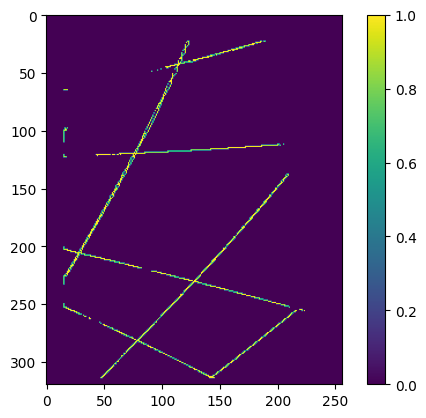

In [8]:
plt.imshow(satellite_data_mask.cpu())
plt.colorbar()

## Визуализация

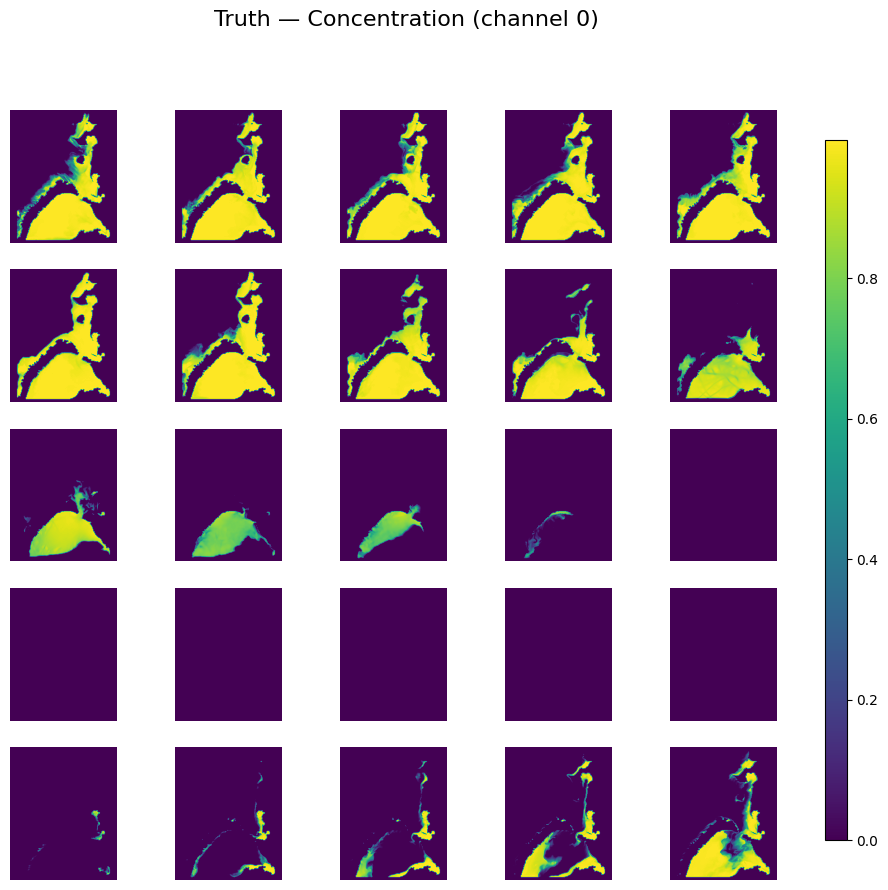

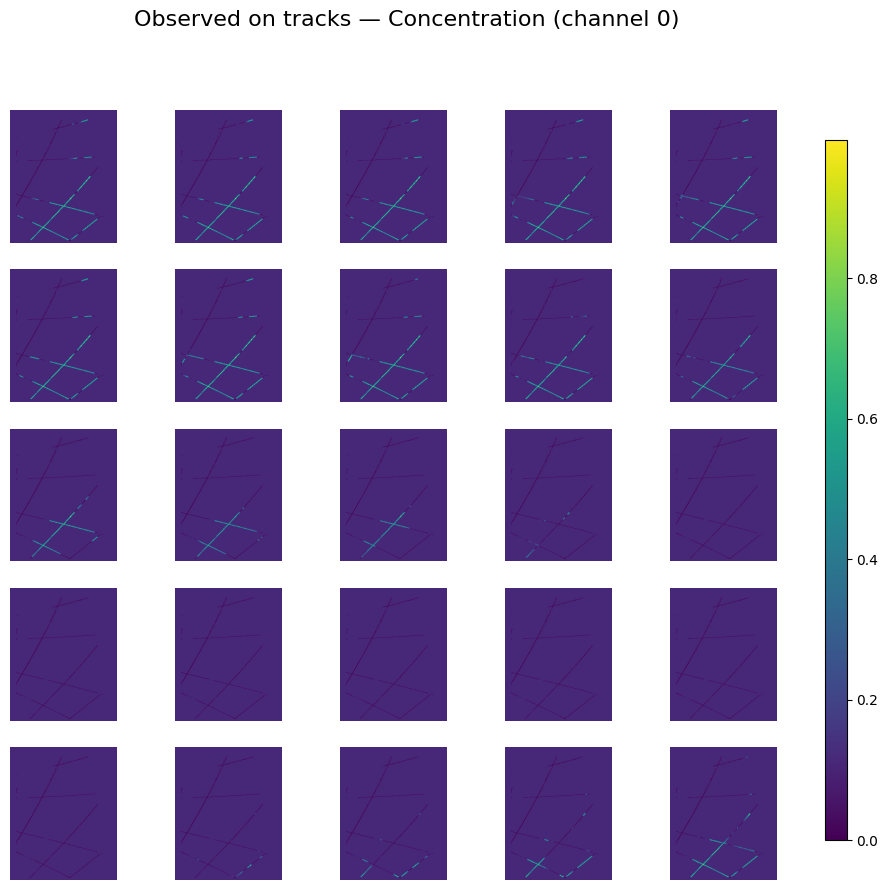

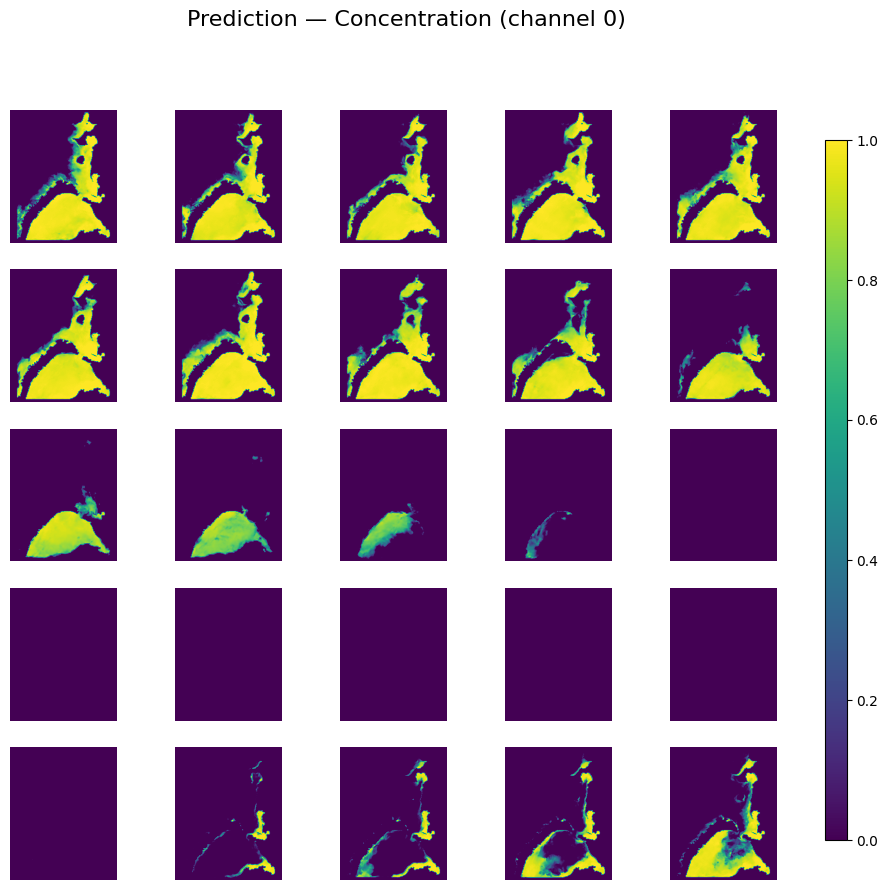

In [9]:
clean_cpu = clean_images.cpu()
pred_cpu  = predictions.cpu()

observed_cpu = clean_cpu * satellite_data_mask.cpu() 

make_plot(clean_cpu,    CHANNEL_MEAN, CHANNEL_STD, N_SAMPLES, title="Truth — Concentration (channel 0)")
make_plot(observed_cpu, CHANNEL_MEAN, CHANNEL_STD, N_SAMPLES, title="Observed on tracks — Concentration (channel 0)")
make_plot(pred_cpu,     CHANNEL_MEAN, CHANNEL_STD, N_SAMPLES, title="Prediction — Concentration (channel 0)")

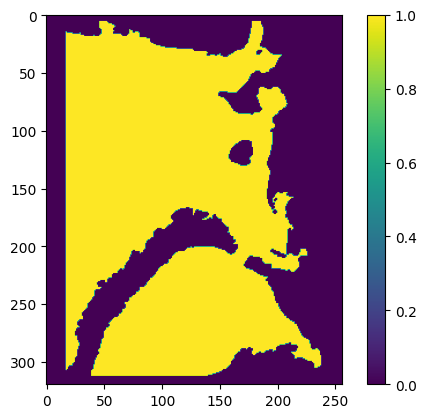

In [10]:
data_example = np.load(r"/mnt/sciml/data_assimilation/da_arctic_2015-2024_v0.1/preds/ocean+atmosphere_24_2015-01-17.npy")
water_mask_initial = np.where(np.isnan(data_example[7, 0, :, :]), 0, 1)
water_mask = np.pad(water_mask_initial, ((4, 5), (15, 16)))
plt.imshow(water_mask)
plt.colorbar()
plt.show()

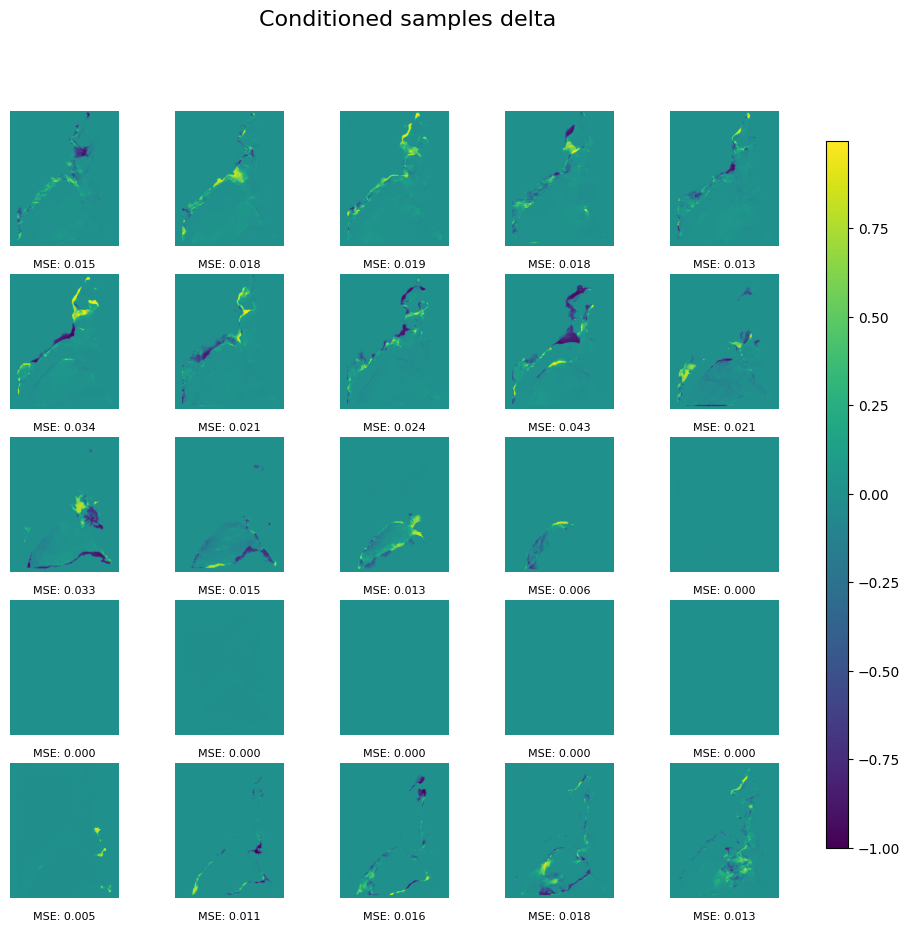

In [11]:
make_difference_plot(clean_cpu, pred_cpu, CHANNEL_MEAN, CHANNEL_STD, N_SAMPLES, land_mask=water_mask)

## Средний MSE по треку

In [12]:
truth_dn = channel_denormalize(clean_images.clone().cpu(), CHANNEL_MEAN, CHANNEL_STD)
pred_dn  = channel_denormalize(predictions.clone().cpu(), CHANNEL_MEAN, CHANNEL_STD)
mask_cpu = satellite_data_mask.cpu()  # (H, W)

diff2 = (truth_dn - pred_dn) ** 2  # (12, 2, H, W)
mask_exp = mask_cpu.unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)

n_pixels = mask_cpu.sum().item()
mse_per_sample = (diff2 * mask_exp).sum(dim=(2, 3)) / n_pixels  # (12, 2)

ch_names = ["Concentration", "Thickness"]
print(f"{'Sample':>8}  {'Concentration MSE':>18}  {'Thickness MSE':>14}")
print("-" * 46)
for i in range(N_SAMPLES):
    print(f"  #{indices[i]:>5}  {mse_per_sample[i,0].item():>18.5f}  {mse_per_sample[i,1].item():>14.5f}")
print("-" * 46)
print(f"  {'mean':>6}  {mse_per_sample[:,0].mean().item():>18.5f}  {mse_per_sample[:,1].mean().item():>14.5f}")

  Sample   Concentration MSE   Thickness MSE
----------------------------------------------
  #    0             0.00031         0.00017
  #  364             0.00034         0.00037
  #  729             0.00043         0.00062
  # 1094             0.00035         0.00058
  # 1459             0.00038         0.00075
  # 1824             0.00042         0.00076
  # 2189             0.00022         0.00109
  # 2554             0.00033         0.00101
  # 2919             0.00048         0.00151
  # 3284             0.00131         0.00441
  # 3649             0.00373         0.02268
  # 4014             0.00046         0.00203
  # 4379             0.00044         0.00223
  # 4744             0.00022         0.00163
  # 5109             0.00000         0.00000
  # 5474             0.00000         0.00000
  # 5839             0.00000         0.00000
  # 6204             0.00000         0.00000
  # 6569             0.00000         0.00000
  # 6934             0.00000         0.00000
  # 7299